# DATASET: Butterfly classificaton

### 31 de mayo de 2026

En el siguiente notebook (creado en Google Colab), se podrá observar el proceso de exportación de datos de un dataset de imágenes proveniente de kaggle, la utilización de archivos CSV para entrenar un modelo ML de clasificación, aumentar la cantidad de imágenes por medio de modificaciones para incrementar la precisión del modelo, y preprocesamiento.

En este caso, se está utilizando un dataset que clasifica mariposas.

In [ ]:
import kagglehub
import os
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Descargar dataset de Butterfly Image Classification
En este bloque se descarga el dataset desde Kaggle.

Cable aclarar que el dataset ya está separado en train y test, contando con directorios diferentes correspondientes a cada uno de los conjuntos. Se importa directamente desde kaggle; cuenta con archivos JPG de las imágenes de las mariposas.

Además, tiene dos archivos de tipo CSV; uno de entrenamiento y uno de pruebas. El CSV de entrenamiento contiene el nombre del archivo y el tipo de mariposa que es. A partir de ahí, se entrena al modelo.

In [ ]:
# Download latest version
path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'butterfly-image-classification' dataset.
Path to dataset files: /kaggle/input/butterfly-image-classification


### Obtener información desde el CSV de Training_set.csv

El dataset contiene un CSV llamado Training_set.csv donde viene el nombre del archivo junto con la clasificación de la mariposa. Se utilizarán estos datos para entrenar al modelo.

In [ ]:
data_csv = pd.read_csv(path + "/Training_set.csv")

data_csv.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [ ]:
from sklearn.model_selection import train_test_split

# Separar el archivo CSV del dataset en 70% entrenamiento y 30% testing
train_csv, test_csv = train_test_split(data_csv, test_size=0.3, random_state=54, stratify=data_csv['label'])

train_csv.head()


,filename,label
47,Image_48.jpg,BANDED PEACOCK
100,Image_101.jpg,BECKERS WHITE
1758,Image_1759.jpg,LARGE MARBLE
5647,Image_5648.jpg,CLOUDED SULPHUR
5602,Image_5603.jpg,ZEBRA LONG WING


In [ ]:

test_csv.head()

,filename,label
806,Image_807.jpg,CRIMSON PATCH
446,Image_447.jpg,SOOTYWING
1628,Image_1629.jpg,COPPER TAIL
3721,Image_3722.jpg,CLODIUS PARNASSIAN
3148,Image_3149.jpg,GREAT JAY


In [ ]:
train_csv["filepath"] = train_csv["filename"].apply(

    lambda x: os.path.join(path, "train", x)

)

train_csv

,filename,label,filepath
47,Image_48.jpg,BANDED PEACOCK,/kaggle/input/butterfly-image-classification/t...
100,Image_101.jpg,BECKERS WHITE,/kaggle/input/butterfly-image-classification/t...
1758,Image_1759.jpg,LARGE MARBLE,/kaggle/input/butterfly-image-classification/t...
5647,Image_5648.jpg,CLOUDED SULPHUR,/kaggle/input/butterfly-image-classification/t...
5602,Image_5603.jpg,ZEBRA LONG WING,/kaggle/input/butterfly-image-classification/t...
...,...,...,...
4988,Image_4989.jpg,GREAT JAY,/kaggle/input/butterfly-image-classification/t...
2383,Image_2384.jpg,BANDED ORANGE HELICONIAN,/kaggle/input/butterfly-image-classification/t...
4705,Image_4706.jpg,CLODIUS PARNASSIAN,/kaggle/input/butterfly-image-classification/t...
3046,Image_3047.jpg,CLODIUS PARNASSIAN,/kaggle/input/butterfly-image-classification/t...


In [ ]:
test_csv["filepath"] = test_csv["filename"].apply(
    lambda x: os.path.join(path, "train", x)
)
test_csv.head()

,filename,label,filepath
806,Image_807.jpg,CRIMSON PATCH,/kaggle/input/butterfly-image-classification/t...
446,Image_447.jpg,SOOTYWING,/kaggle/input/butterfly-image-classification/t...
1628,Image_1629.jpg,COPPER TAIL,/kaggle/input/butterfly-image-classification/t...
3721,Image_3722.jpg,CLODIUS PARNASSIAN,/kaggle/input/butterfly-image-classification/t...
3148,Image_3149.jpg,GREAT JAY,/kaggle/input/butterfly-image-classification/t...


### Llevar a cabo la augmentation
En esta sección, se lleva a cabo la aumentación de datos. Se utiliza el comando ImageDataGenerator importado de tensorflow, y se generan las imágenes nuevas a partir del mismo.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

# Se generan las imágenes con los parámetros de modificación especificados
train_datagen = ImageDataGenerator(
    rescale = 1./255, # convierte los valores de los pixeles a un número entre 0-1
    # rotation_range = 10, # rango de grados para rotar la imagen
    width_shift_range = 0.2, # rango de porcentaje para incrementar el ancho
    height_shift_range = 0.2, # rango de porcentaje para incrementar la altura
    # shear_range = 0.3, # rango de % aplicar transformaciones de deformación
    # zoom_range = 0.3, # rango de % para aplicar transformaciones de zoom
    horizontal_flip = True,
    validation_split = 0.2 # Allocate 20% of the training data for validation
)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_csv,
    x_col="filepath", # path del archivo
    y_col="label",
    target_size = (64, 64),
    batch_size = 8,
    class_mode='categorical', # ya que son múltiples categorías
    subset='training'
  )

images, labels = train_generator[0]

# Se obtiene el objeto de los índicies de las clases
# a partir de lo que se generó en train_generator
class_indices = train_generator.class_indices

# DataFrame para visualizar las clases posibles
class_indices_df = pd.DataFrame.from_dict(class_indices, orient='index', columns=['Number'])

class_indices_df



Found 3640 validated image filenames belonging to 75 classes.


,Number
ADONIS,0
AFRICAN GIANT SWALLOWTAIL,1
AMERICAN SNOOT,2
AN 88,3
APPOLLO,4
...,...
ULYSES,70
VICEROY,71
WOOD SATYR,72
YELLOW SWALLOW TAIL,73


In [ ]:
val_generator = train_datagen.flow_from_dataframe(
    dataframe=train_csv,
    x_col='filepath',
    y_col='label',
    target_size=(64,64),
    batch_size=8,
    class_mode='categorical',
    subset='validation'
)

Found 909 validated image filenames belonging to 75 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_csv,
    x_col="filepath",
    y_col="label",
    target_size=(64, 64),
    batch_size = 8,
    class_mode='categorical',
    shuffle=False
)

print(f"Number of test images: {test_generator.samples}")

Found 1950 validated image filenames belonging to 75 classes.
Number of test images: 1950


### Visualización
Se imprimen las imágenes generadas para la aumentación junto con el tipo de mariposa que son.

<Figure size 640x480 with 0 Axes>

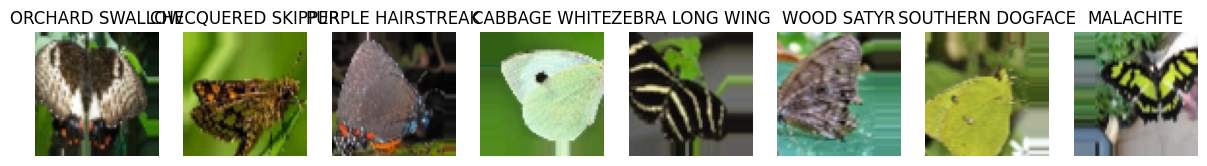

<Figure size 640x480 with 0 Axes>

In [ ]:
# Se voltea el orden del diccionario class_indices para que sea
# índice: valor en lugar de valor: índice
idx_to_class = {v: k for k, v in class_indices.items()}

f, axarr = plt.subplots(1, images.shape[0], figsize=(15, 4))

for i in range(images.shape[0]):
  axarr[i].imshow(images[i])
  class_index = labels[i].argmax()
  class_name = idx_to_class[class_index]
  axarr[i].set_title(class_name) # configurar el nombr de la clase de mariposa
  axarr[i].axis("off")

plt.figure()

### CNN para el modelo de análisis

In [ ]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint

num_classes = len(class_indices)

model = models.Sequential()

model.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (64,64,3)))
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))

# Activación softmax en vez de sigmoid porque existen múltiples clases
model.add(layers.Dense(num_classes, activation='softmax'))

model.summary()

model.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=1e-4),
						metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 10)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 38440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,840,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 75)             │        19,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,860,451 (37.61 MB)

 Trainable params: 9,860,451 (37.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Entrenamiento del modelo
Se ejecuta el entrenamiento del modelo (en este caso únicamente en una época) y se grafica utilizando matplotlib para generar dos gráficos; uno que muestre la evolución del valor de accuracy y otro que muestra la evolución de loss.

Cuando existen más épocas hay mayor cantidad de puntos que muestran cómo evoluciona el entrenamiento del modelo; si sube el loss o baja, si el accuracy incrementa, etc.

In [ ]:
checkpoint_filepath = '/content/drive/MyDrive/emotion_model.keras'

loaded_model = tf.keras.models.load_model(checkpoint_filepath)

print(f"Model loaded successfully from: {checkpoint_filepath}")
loaded_model.summary()

Model loaded successfully from: /content/drive/MyDrive/emotion_model.keras


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 10)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 38440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,840,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 75)             │        19,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,720,904 (75.23 MB)

 Trainable params: 9,860,451 (37.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,860,453 (37.61 MB)

In [ ]:
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

In [ ]:
import os

os.path.exists(checkpoint_filepath)

True

In [ ]:
history = model.fit(
	train_generator,
	validation_data = val_generator,
	epochs = 250, # Épocas
  callbacks=[model_checkpoint_callback]
)


Epoch 1/250
453/455 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.0279 - loss: 4.3064

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


455/455 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - acc: 0.0368 - loss: 4.2078 - val_acc: 0.0418 - val_loss: 4.0802
Epoch 2/250
455/455 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - acc: 0.0736 - loss: 3.8878 - val_acc: 0.1111 - val_loss: 3.7499
Epoch 3/250
455/455 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - acc: 0.1055 - loss: 3.6418 - val_acc: 0.1177 - val_loss: 3.6555
Epoch 4/250
455/455 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - acc: 0.1363 - loss: 3.4456 - val_acc: 0.1408 - val_loss: 3.4740
Epoch 5/250
455/455 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - acc: 0.1582 - loss: 3.3171 - val_acc: 0.1474 - val_loss: 3.3585
Epoch 6/250
455/455 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - acc: 0.1835 - loss: 3.2044 - val_acc: 0.1749 - val_loss: 3.2584
Epoch 7/250
455/455 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - acc: 0.1860 - loss: 3.1427 - val_acc: 0.1782 - val_loss: 3.2268
Epoch 8/250
455/455 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - acc: 0.2091 - loss: 3.0515 - val_acc: 0.2024 - val_loss: 3.1329
Epoch 9/250
455/455 ━━━━━━━━━━━━━━━━━━━━ 16s

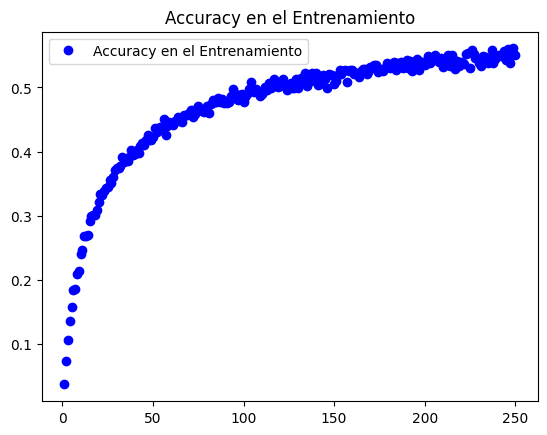

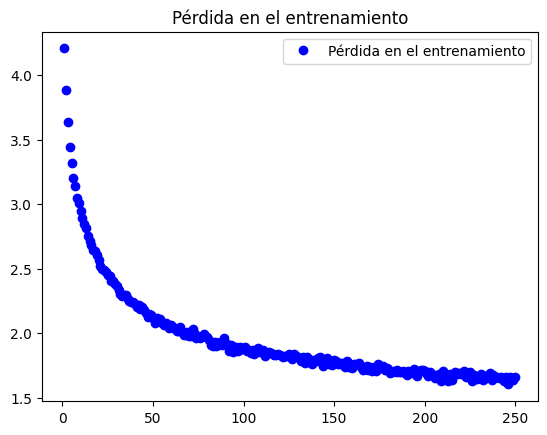

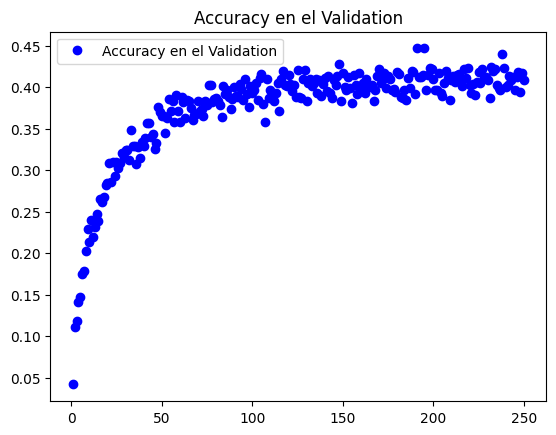

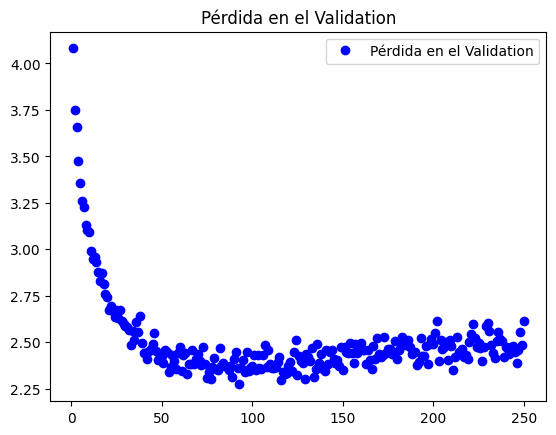

In [ ]:
acc = history.history['acc']
loss = history.history['loss']
val = history.history['val_acc']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='Accuracy en el Entrenamiento')
plt.title('Accuracy en el Entrenamiento')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='Pérdida en el entrenamiento')
plt.title('Pérdida en el entrenamiento')
plt.legend()

plt.show()

plt.plot(epochs,val,'bo',label='Accuracy en el Validation')
plt.title('Accuracy en el Validation')
plt.legend()

plt.figure()

plt.plot(epochs,val_loss, 'bo', label ='Pérdida en el Validation')
plt.title('Pérdida en el Validation')
plt.legend()

plt.show()

### Evaluación del modelo
Ahora, evaluaremos el modelo entrenado utilizando el conjunto de datos de prueba (`test_generator`) para determinar su rendimiento en datos no vistos.

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - acc: 0.4374 - loss: 2.8378
Test accuracy: 0.43743589520454407
Test loss: 2.8377647399902344


### Matriz de Confusión
Ahora, generaremos una matriz de confusión para visualizar el rendimiento del modelo en cada clase. Esto nos permitirá identificar qué clases el modelo clasifica correctamente y cuáles confunde.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)


244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


In [ ]:
print(predicted_classes)

[67 33 56 ... 71 66 27]


In [ ]:
true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

### Matrices de Confusión Divididas
Para una mejor visualización, dividiremos la matriz de confusión completa en sub-matrices, mostrando 15 clases en cada una.

<Figure size 1500x1500 with 0 Axes>

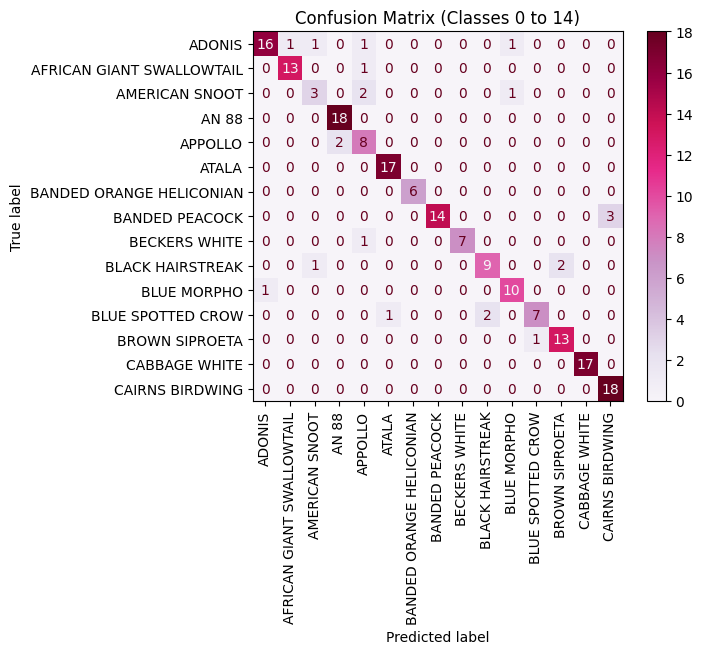

<Figure size 1500x1500 with 0 Axes>

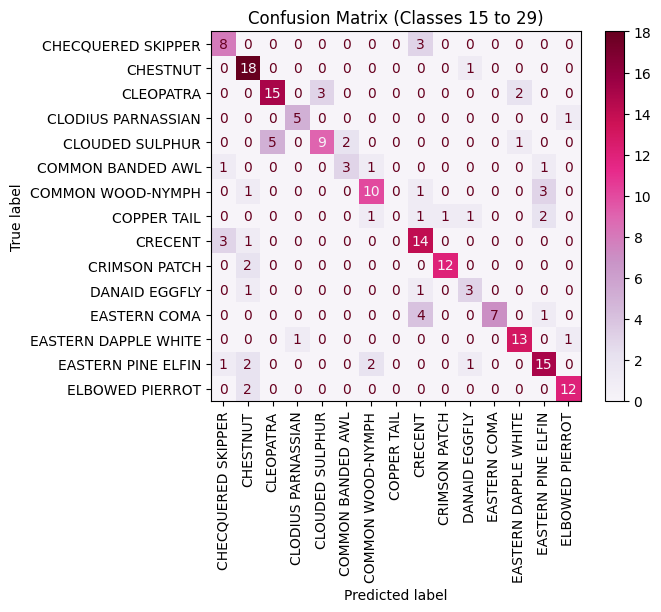

<Figure size 1500x1500 with 0 Axes>

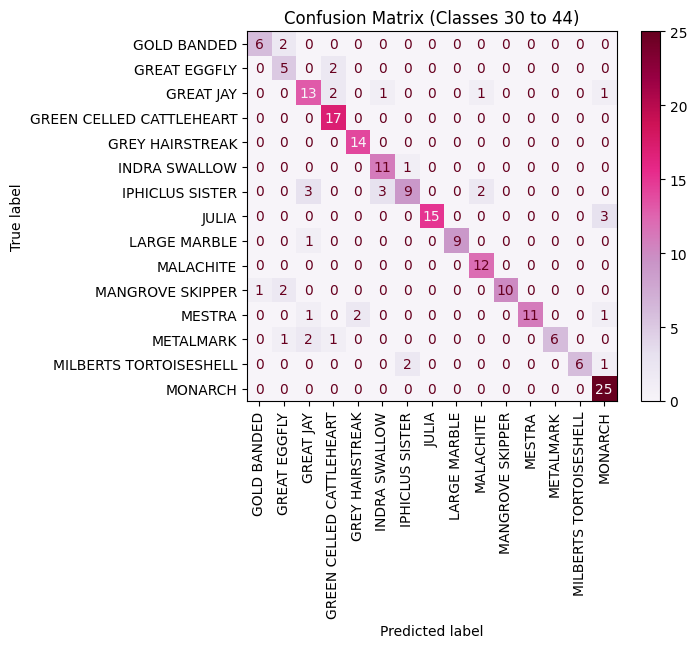

<Figure size 1500x1500 with 0 Axes>

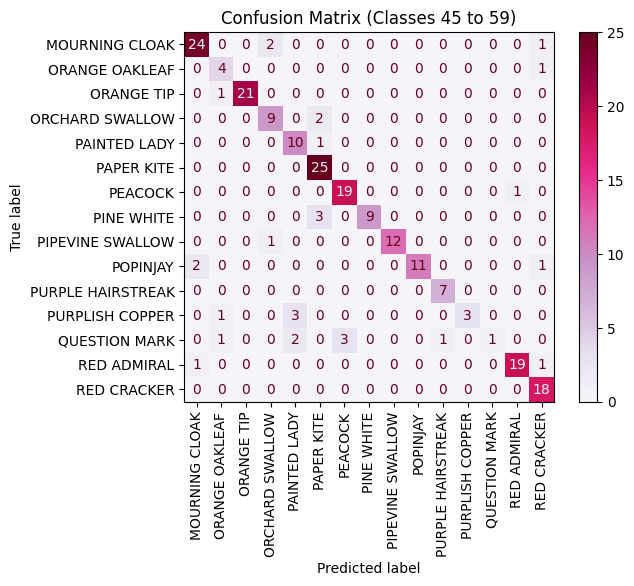

<Figure size 1500x1500 with 0 Axes>

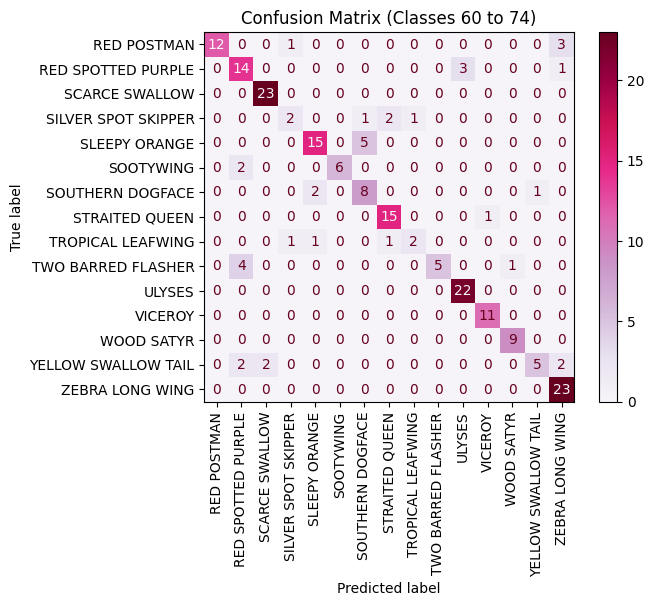

In [ ]:
classes_per_matrix = 15

num_sub_matrices = (len(class_labels) + classes_per_matrix - 1) // classes_per_matrix

for i in range(num_sub_matrices):
    start_index = i * classes_per_matrix
    end_index = min((i + 1) * classes_per_matrix, len(class_labels))

    sub_class_labels = class_labels[start_index:end_index]

    sub_cm = cm[start_index:end_index, start_index:end_index]

    plt.figure(figsize=(15, 15))
    disp = ConfusionMatrixDisplay(confusion_matrix=sub_cm, display_labels=sub_class_labels)
    disp.plot(cmap=plt.cm.PuRd, xticks_rotation='vertical')
    plt.title(f'Confusion Matrix (Classes {start_index} to {end_index-1})')
    plt.show()

In [ ]:
print(len(class_labels))